In [1]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [8]:
numerical_column=df.select_dtypes(include=["int64","float64"]).columns
print(numerical_column)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


In [9]:
categorical_columns=df.select_dtypes(include=["object"]).columns
print(categorical_columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


C:\Users\rangi\AppData\Local\Temp\ipykernel_13740\806332730.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=df.select_dtypes(include=["object"]).columns


In [10]:
X=df.drop(["Churn","customerID"],axis=1)
y=df["Churn"]

In [11]:
X["TotalCharges"]=pd.to_numeric(X["TotalCharges"],errors="coerce")

In [12]:
X["TotalCharges"].isnull().sum()

np.int64(11)

In [13]:
X["TotalCharges"]=X["TotalCharges"].fillna(0)

In [14]:
numerical_column=X.select_dtypes(include=["int64","float64"]).columns
categorical_columns=X.select_dtypes(include=["object","string"]).columns

In [15]:
print(numerical_column)
print(categorical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [16]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)

In [17]:
print(y[:10])

[0 0 1 0 1 1 0 0 1 0]


In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded_data=encoder.fit_transform(X[categorical_columns])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(categorical_columns),index=X.index)
X_encoded=pd.concat([X[numerical_column], encoded_df],axis=1)
X_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_temp,y_train,y_temp=train_test_split(X_encoded,y,test_size=0.3,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)



In [31]:
import torch

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
X_val_tensor=torch.tensor(X_val_scaled,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train,dtype=torch.float32).reshape(-1,1)
y_val_tensor=torch.tensor(y_val,dtype=torch.float32).reshape(-1,1)
y_test_tensor=torch.tensor(y_test,dtype=torch.float32).reshape(-1,1)



In [32]:
import torch
import torch.nn as nn


In [33]:
input_size=X_train_tensor.shape[1]
print(input_size)

30


In [34]:
class ChurnNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1),
        nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

In [35]:
model = ChurnNeuralNetwork(input_size)


In [36]:
model.eval()
with torch.no_grad():
    sample_output=model(X_train_tensor[:5])

In [37]:
criterion = nn.BCELoss()


In [38]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [40]:
model.train()
predictions=model(X_train_tensor)
loss=criterion(predictions,y_train_tensor)
optimizer.zero_grad()
loss.backward()
optimizer.step()
loss.item()

0.5897423028945923

In [41]:
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    predictions = model(X_train_tensor)

    train_loss = criterion(
        predictions,
        y_train_tensor
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    # --------------------
    # Validation
    # --------------------
    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val_tensor)

        val_loss = criterion(
            val_predictions,
            y_val_tensor
        )

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Train Loss: {train_loss.item():.4f} "
            f"Val Loss: {val_loss.item():.4f}"
        )

Epoch 10/100 Train Loss: 0.4453 Val Loss: 0.4254
Epoch 20/100 Train Loss: 0.4182 Val Loss: 0.4092
Epoch 30/100 Train Loss: 0.4085 Val Loss: 0.4123
Epoch 40/100 Train Loss: 0.3999 Val Loss: 0.4084
Epoch 50/100 Train Loss: 0.3913 Val Loss: 0.4097
Epoch 60/100 Train Loss: 0.3814 Val Loss: 0.4157
Epoch 70/100 Train Loss: 0.3704 Val Loss: 0.4250
Epoch 80/100 Train Loss: 0.3589 Val Loss: 0.4350
Epoch 90/100 Train Loss: 0.3500 Val Loss: 0.4567
Epoch 100/100 Train Loss: 0.3334 Val Loss: 0.4574


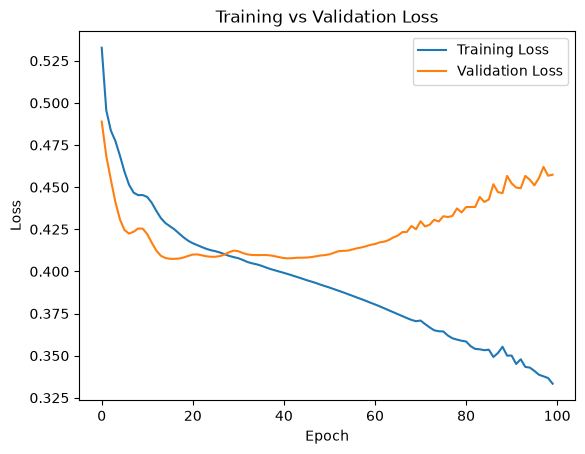

In [42]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [43]:
model.eval()

with torch.no_grad():
    test_probabilities = model(X_test_tensor)

print(test_probabilities[:10])


tensor([[0.0057],
        [0.0533],
        [0.0183],
        [0.0469],
        [0.1579],
        [0.1748],
        [0.5530],
        [0.0372],
        [0.1483],
        [0.0261]])


In [44]:
test_predictions = (test_probabilities >= 0.5).int()

print(test_predictions[:10])

tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0]], dtype=torch.int32)


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = y_test_tensor.numpy()
y_pred = test_predictions.numpy()

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.7871333964049196
Precision: 0.6485355648535565
Recall   : 0.5236486486486487
F1 Score : 0.5794392523364486


In [47]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    test_probabilities.numpy()
)

print("ROC-AUC:", auc)

ROC-AUC: 0.838452693823916


In [46]:
print(confusion_matrix(y_true, y_pred))


[[677  84]
 [141 155]]


In [48]:
customer = X_test_tensor[0].unsqueeze(0)

model.eval()

with torch.no_grad():
    probability = model(customer)

print("Churn probability:", probability.item())

Churn probability: 0.0056586978025734425


In [49]:
prediction = (probability >= 0.5).int()

print("Prediction:", prediction.item())

Prediction: 0


In [50]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model.state_dict(),
    "models/churn_model.pth"
)

In [51]:
import joblib

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [52]:
joblib.dump(
    encoder,
    "models/encoder.pkl"
)

['models/encoder.pkl']

In [53]:
joblib.dump(
    X_encoded.columns.tolist(),
    "models/feature_names.pkl"
)

['models/feature_names.pkl']

In [ ]:
loaded_encoder = joblib.load(
    "models/encoder.pkl"
)

loaded_scaler = joblib.load(
    "models/scaler.pkl"
)

loaded_features = joblib.load(
    "models/feature_names.pkl"
)

In [54]:
loaded_model = ChurnNeuralNetwork(input_size)

loaded_model.load_state_dict(
    torch.load(
        "models/churn_model.pth",
        weights_only=True
    )
)

loaded_model.eval()

ChurnNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [55]:
customer = X_test_tensor[0].unsqueeze(0)

with torch.no_grad():
    original_prediction = model(customer)
    loaded_prediction = loaded_model(customer)

print("Original :", original_prediction.item())
print("Loaded   :", loaded_prediction.item())

Original : 0.0056586978025734425
Loaded   : 0.0056586978025734425
